In [1]:
%%sh
if [ ! -f flowers-recognition.zip ] 
then
   kaggle datasets download -d alxmamaev/flowers-recognition
fi
if [ ! -d flowers ] 
then
   unzip flowers-recognition.zip >/dev/null
fi

In [2]:
# License: BSD
# Author: Sasank Chilamkurthy

from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset,DataLoader,random_split
import matplotlib.pyplot as plt
import time
import os
import copy

cudnn.benchmark = True
plt.ion()   # interactive mode

In [3]:
class MyDataset(Dataset):
    def __init__(self,subset,transform=None):
        self.subset=subset
        self.transform=transform
    def __getitem__(self,idx):
        x,y=self.subset[idx]
        if self.transform:
            x=self.transform(x)
        return x,y
    def __len__(self):
        return len(self.subset)

In [4]:
augment_choices={'trivial':transforms.TrivialAugmentWide(),'random':transforms.RandAugment(),
                 'mix':transforms.AugMix(),'auto':transforms.AutoAugment()}
aug='trivial'

In [5]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
     'train': 
        transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(180),
        transforms.ToTensor(),
        #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        transforms.Normalize([0., 0., 0.], [1., 1., 1.])
    ]) if aug=='None' else
     
     transforms.Compose([
        transforms.TrivialAugmentWide(),
        transforms.CenterCrop(180),
        transforms.ToTensor(),
        #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        transforms.Normalize([0., 0., 0.], [1., 1., 1.])
    ]) 
    ,
    # 'train': transforms.Compose([
    #     transforms.RandomResizedCrop(180),
    #     transforms.RandomHorizontalFlip(),
    #     transforms.ToTensor(),
    #     transforms.Normalize([0., 0., 0.], [1., 1., 1.])
    # ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(180),
        transforms.ToTensor(),
        #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        transforms.Normalize([0., 0., 0.], [1., 1., 1.])
    ])
}

dataset=torchvision.datasets.ImageFolder("flowers")
class_names=dataset.classes
train_d,valid_d=random_split(dataset,lengths=[0.8,0.2])

datasets={'train':train_d,'val':valid_d}
#train_dt=MyDataset(train_d,data_transforms['train'])
#valid_dt=MyDataset(valid_d,data_transforms['val'])


#data_dir = 'hymenoptera_data'ageFolder(os.path.join(data_dir, x)
image_datasets = {x: MyDataset(datasets[x],data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32,
                                             shuffle=True, num_workers=2)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

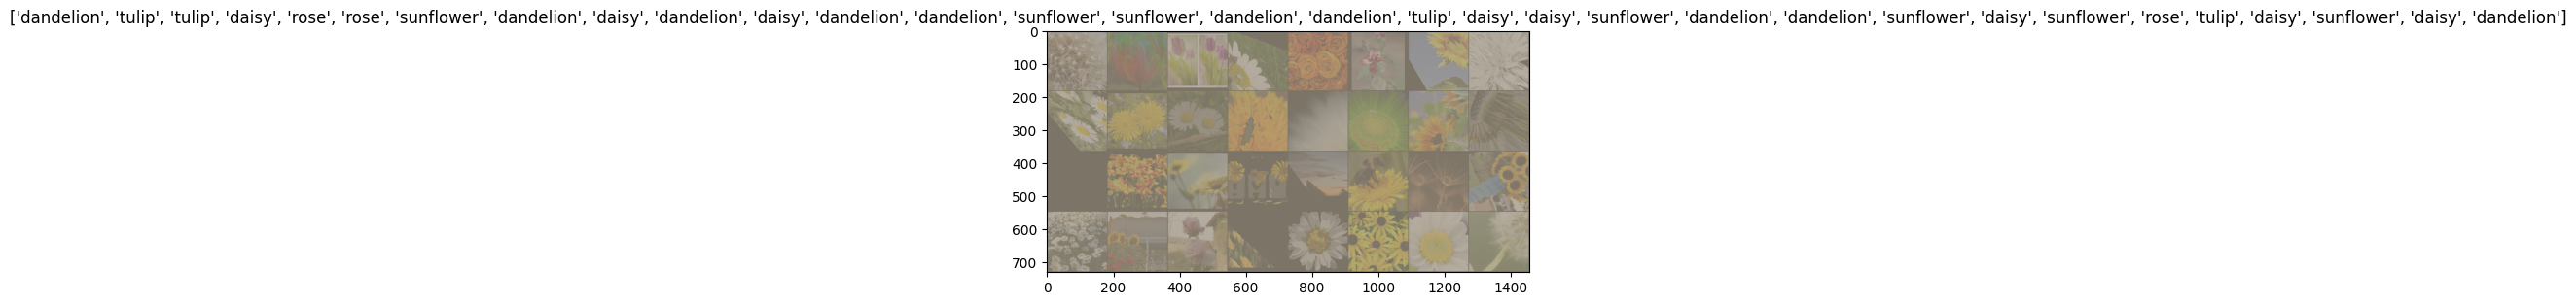

In [6]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [7]:
from torch.utils.tensorboard import SummaryWriter
import datetime
%load_ext tensorboard
current=datetime.datetime.now()
log_dir = 'logs/tensorboard/' +aug+'-'+current.strftime("%c")
writer=SummaryWriter(log_dir)

In [8]:
def evaluate(model, criterion):
    phase='val'
    model.eval()   

    running_loss = 0.0
    running_corrects = 0
    for inputs, labels in dataloaders['val']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        
    epoch_loss = running_loss / dataset_sizes['val']
    epoch_acc = running_corrects.double() / dataset_sizes['val']
    return epoch_loss,epoch_acc

In [9]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=100):
    phase='train'
    for epoch in range(num_epochs):
        
        model.train()  # Set model to training mode
        running_loss = 0.0
        running_corrects = 0
        
            # Iterate over data.
        for inputs, labels in dataloaders['train']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

                # statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        
        scheduler.step()

        epoch_loss = running_loss / dataset_sizes['train']
        epoch_acc = running_corrects.double() / dataset_sizes['train']
        v_loss,v_acc=evaluate(model,criterion)
        writer.add_scalar("Epoch loss",epoch_loss,epoch)
        writer.add_scalars("loss",{'train':epoch_loss,'valid':v_loss},epoch)
        writer.add_scalars("acc",{'train':epoch_acc,'valid':v_acc},epoch)
        if epoch%5==0:
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)
            
            print("t_loss={:.4f},t_acc={:.4f}".format(epoch_loss,epoch_acc))
            print("v_loss={:.4f},v_acc={:.4f}".format(v_loss,v_acc))
    return model

In [10]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [11]:
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [12]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=30)

Epoch 0/29
----------
t_loss=0.8205,t_acc=0.6925
v_loss=0.3739,v_acc=0.8714
Epoch 5/29
----------
t_loss=0.2216,t_acc=0.9198
v_loss=0.2642,v_acc=0.9061
Epoch 10/29
----------
t_loss=0.1517,t_acc=0.9508
v_loss=0.2395,v_acc=0.9189
Epoch 15/29
----------
t_loss=0.1541,t_acc=0.9467
v_loss=0.2376,v_acc=0.9154
Epoch 20/29
----------
t_loss=0.1367,t_acc=0.9548
v_loss=0.2309,v_acc=0.9212
Epoch 25/29
----------
t_loss=0.1483,t_acc=0.9514
v_loss=0.2372,v_acc=0.9177


In [ ]:
visualize_model(model_ft)

In [ ]:
model_conv = torchvision.models.resnet18(models.ResNet18_Weights.DEFAULT)
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, len(class_names))

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.005, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=20, gamma=0.1)

In [ ]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=100)

In [ ]:
visualize_model(model_conv)

plt.ioff()
plt.show()

In [ ]:
%tensorboard --logdir logs/tensorboard